SATAFFING OPTIMIZATION PROJECT
The primary objective of this project is to forecast daily staffing requirements for a hotel in Glasnevin area. These predictions are based on historical weather data, local events and past hotel occupancy. Accurate forecasting will help to prevent overstaffing and understaffing, ensuring optimal staff distribution, improve customer service and reduce the payroll waste. 



In [1]:
#Important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score



WEATHER DATA SET
In this section I imported 3 data sets from Met Eireann for the years 2015, 2016 and 2017. They contain key features like date, rainfall, min and max temperature, which are essential to determine the impact of the weather on the hotel. I merged this 3 datasets and created a new feature to classify weather into three distinct categories: Good/warm, Dry/Cool, and Poor/Wet

In [2]:
#Import the 3 data sets from Met Eireann, the sets are clean and organized, the main task here is to merge them and create the conditionals that
#will determine how a good weather looks like to impact the hotel ocupancy
df_15 = pd.read_csv("DataSets/dly1823_subset 2015.csv", skiprows=13)
df_16 = pd.read_csv("DataSets/dly1823_subset 2016.csv", skiprows=13 )
df_17 = pd.read_csv("DataSets/dly1823_subset 2017.csv", skiprows=13)



df = pd.concat([df_15, df_16, df_17], ignore_index=True)#Combine into one master weather dataframe

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1096 non-null   object 
 1   ind     1096 non-null   int64  
 2   rain    1096 non-null   float64
 3   ind.1   1096 non-null   int64  
 4   maxt    1096 non-null   float64
 5   ind.2   1096 non-null   int64  
 6   mint    1096 non-null   float64
 7   gmin    1096 non-null   float64
 8   soil    1096 non-null   object 
dtypes: float64(4), int64(3), object(2)
memory usage: 77.2+ KB


In [3]:
df.head

<bound method NDFrame.head of              date  ind  rain  ind.1  maxt  ind.2  mint  gmin soil
0     01-jan-2015    0   2.6      0  15.0      0  10.4   8.0     
1     02-jan-2015    0   7.7      0   8.0      0   4.6   3.2     
2     03-jan-2015    0   1.1      0   5.9      0   4.3   3.0     
3     04-jan-2015    4   0.0      0   9.7      1  -1.6  -5.0     
4     05-jan-2015    0   1.1      0  11.6      1  -1.1  -4.1     
...           ...  ...   ...    ...   ...    ...   ...   ...  ...
1091  27-dec-2017    0   0.0      0   4.8      0   1.0  -2.0     
1092  28-dec-2017    0   2.8      0   6.8      1  -0.7  -3.6     
1093  29-dec-2017    0  13.9      0   9.4      1  -0.4  -3.1     
1094  30-dec-2017    0   0.2      0  12.5      0   2.0   0.4     
1095  31-dec-2017    0   0.5      0  12.5      0   7.3   5.1     

[1096 rows x 9 columns]>

In [4]:
df_filtered = df [["date", "rain", "maxt", "mint"]] #Now I'll filter only the freatures that impact my model.
df_filtered.head()

,date,rain,maxt,mint
0,01-jan-2015,2.6,15.0,10.4
1,02-jan-2015,7.7,8.0,4.6
2,03-jan-2015,1.1,5.9,4.3
3,04-jan-2015,0.0,9.7,-1.6
4,05-jan-2015,1.1,11.6,-1.1


In [5]:
df_filtered.isnull().sum()

date    0
rain    0
maxt    0
mint    0
dtype: int64

Weather Quality needs to be categorized to simplify raw data into categorical signals, to make it easy for everyone to interpret, including the model. 

In [6]:
df_filtered = df[["date", "rain", "maxt", "mint"]].copy()
conditions = [
    #Good/Warm: Less than 1mm rain AND 16C or warmer
    (df_filtered["rain"] < 1.0) & (df_filtered["maxt"] >= 13),
    
    #Dry/Cool: Less than 1mm rain AND cooler than 16C
    (df_filtered["rain"] < 1.0) & (df_filtered["maxt"] < 13),
    
    #Poor/Wet: 5mm+ of rain OR very cold (under 5C max)
    (df_filtered["rain"] >= 5.0) | (df_filtered["maxt"] < 8),
]

choices = ["Good/Warm", "Dry/Cool", "Poor/Wet"]

# Apply the choices, everything else becomes 'Moderate/Changeable'
df_filtered["weather_quality"] = np.select(conditions, choices, default="Moderate/Changeable")

df_filtered.head(10)

,date,rain,maxt,mint,weather_quality
0,01-jan-2015,2.6,15.0,10.4,Moderate/Changeable
1,02-jan-2015,7.7,8.0,4.6,Poor/Wet
2,03-jan-2015,1.1,5.9,4.3,Poor/Wet
3,04-jan-2015,0.0,9.7,-1.6,Dry/Cool
4,05-jan-2015,1.1,11.6,-1.1,Moderate/Changeable
5,06-jan-2015,0.3,10.0,3.3,Dry/Cool
6,07-jan-2015,5.9,12.9,4.2,Poor/Wet
7,08-jan-2015,2.0,10.5,5.4,Moderate/Changeable
8,09-jan-2015,7.2,15.4,5.4,Poor/Wet
9,10-jan-2015,0.0,6.3,5.6,Dry/Cool


DUBLIN EVENTS DATA SET 
This data set was created with the help of AI to find all the past events from 2015 to 2017 that can impact the Glasnevin area. This data set will help to predict the events that can impact the hotel occupancy. 
I specifically created the list of events with the "date" column in the same format than weather data set, so I can merge them together. 

In [7]:
df_events = pd.read_csv("DataSets/dublin_events_2015_2017.csv")
df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1096 non-null   object
 1   event_name    1096 non-null   object
 2   event_impact  1096 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 25.8+ KB


In [8]:
df_events.head(10) #first overview of the data set

,date,event_name,event_impact
0,1/1/2015,No Event,0
1,2/1/2015,No Event,0
2,3/1/2015,No Event,0
3,4/1/2015,No Event,0
4,5/1/2015,No Event,0
5,6/1/2015,No Event,0
6,7/1/2015,No Event,0
7,8/1/2015,No Event,0
8,9/1/2015,No Event,0
9,10/1/2015,No Event,0


In [9]:
df_events.isnull().sum()

date            0
event_name      0
event_impact    0
dtype: int64

In [10]:
df_filtered["date"] = pd.to_datetime(df_filtered["date"], format="mixed", dayfirst="TRUE") # I can see all the rows share the same date format so now I can merge based on that
df_events["date"] = pd.to_datetime(df_events["date"], format="mixed", dayfirst="TRUE")

df_merged = pd.merge(df_filtered, df_events, on= "date", how="left")


In [11]:
df_merged["event_impact"] = df_merged["event_impact"].fillna(0) # on the df the days that we dont have events should be marked as 0
df_merged["event_name"] = df_merged["event_name"].fillna("No Event") # and the name as No event, insted of just saying NAN
df_merged.head()
#Event impact 0 means no event, 1 means we have an event that may or not impact the bussiness and 2 means an event that definetely impact the bussiness

,date,rain,maxt,mint,weather_quality,event_name,event_impact
0,2015-01-01,2.6,15.0,10.4,Moderate/Changeable,No Event,0
1,2015-01-02,7.7,8.0,4.6,Poor/Wet,No Event,0
2,2015-01-03,1.1,5.9,4.3,Poor/Wet,No Event,0
3,2015-01-04,0.0,9.7,-1.6,Dry/Cool,No Event,0
4,2015-01-05,1.1,11.6,-1.1,Moderate/Changeable,No Event,0


HOTEL OCCUPANCY DATA SET
The occupancy data set was sourced from Kaggle. Because the original data sets do not align with my actual Dublin weather and events data I decided to protect the integrity of the model by using only the overlapping period of July 1st 2015 to 31st August 2017. I also combined the adults and childs columns to calculate the total guest volume and I matched the date format as the rest of the data sets. 

In [12]:
df_hotel = pd.read_csv("DataSets/hotel_bookings.csv")
df_hotel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [13]:
df_hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [14]:
df_hotel.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [15]:
df_hotel["children"].shape[0]

119390

In [16]:
print("Hotels found in data:", df_hotel["hotel"].unique()) #I can see the set contain more than one hotel, I'll get rid onf one

Hotels found in data: ['Resort Hotel' 'City Hotel']


In [17]:
df_single_hotel = df_hotel[df_hotel["hotel"] == "City Hotel"].copy() # I choose to stay with City Hotel

In [18]:
print("Hotels found in data:", df_single_hotel["hotel"].unique()) # Now I can confirm I only have one hotel to analyse

Hotels found in data: ['City Hotel']


In [19]:
 print(df_single_hotel["arrival_date_year"].unique()) #And I just confirm I have data on the years I need

[2015 2016 2017]


In [20]:
#By looking at the columns I can see that the information I need is in "adults", I only focus on how many people stayed per nigth and I'll include "kids" too
df_single_hotel["total_people"] = df_single_hotel["adults"] + df_single_hotel["children"].fillna(0)

In [21]:
df_single_hotel.isnull().sum() #I just verify that adults and children have 0 null values 

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                              24
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                              8131
company                           75641


In [22]:
#I mapped the months, since on the data set they have different formatting, I have to reset the dates to make them fit with my other sets
month_map= {"January":1, "February":2, "March":3, "April":4, "May":5, "June":6, 
             "July":7, "August":8, "September":9, "October":10, "November":11, "December":12}
df_single_hotel["month_num"] = df_single_hotel["arrival_date_month"].map(month_map)

In [23]:
df_single_hotel['date'] = pd.to_datetime({ # now combine year, month and day in to my df
    "year": df_single_hotel["arrival_date_year"],
    "month": df_single_hotel["month_num"],
    "day": df_single_hotel["arrival_date_day_of_month"]
})

In [24]:
print(df_single_hotel["is_canceled"].value_counts())

is_canceled
0    46228
1    33102
Name: count, dtype: int64


In [25]:
#The occupancy have to be made of 1 the amount of people who arrived, 2 the nigths they stayed and 3 make sure they didnt show up
rows = []
for _, row in df_single_hotel[df_single_hotel["is_canceled"] == 0].iterrows():#This is the filter to look fot the cancelations. 
    stay_length = int(row["stays_in_weekend_nights"] + row["stays_in_week_nights"]) # unifying weekends and weedays of my data set  
    if stay_length == 0: #skip the 0 nigths stay and continue
        continue
    for i in range(stay_length): #This is the logic if the client arrives the 1s july and stay 2 nigths, then we'll need to considare staff up to the 2nd july
        night = row["date"] + pd.Timedelta(days=i)#Timedelta is the masterpiece of my code, this creates a "chunk of time", in thi case
                                               #a number of days. When i=1, it creates 1 day and add it to the date
        rows.append({"date": night, "guests": row["total_people"]})

df_nightly = pd.DataFrame(rows)#At this point I have one row per guest per night, many rows for the same date if multiple bookings overlap
df_occupancy = df_nightly.groupby("date")["guests"].sum().reset_index()#Groups all entries that share the same date together
df_occupancy.rename(columns={"guests": "occupancy"}, inplace=True)

daily_adr = df_single_hotel.groupby("date")["adr"].mean().reset_index()

df_occupancy.head(10)




####This specific date-expansion(Timedelta) algorithm was co-developed via personal communication with C. Rosales (2026)."#####

,date,occupancy
0,2015-07-01,116.0
1,2015-07-02,117.0
2,2015-07-03,24.0
3,2015-07-04,40.0
4,2015-07-05,23.0
5,2015-07-06,20.0
6,2015-07-07,23.0
7,2015-07-08,54.0
8,2015-07-09,53.0
9,2015-07-10,14.0


FINAL MERGE : With the three datasets prepared. I performed a final merge on the "date" column. 

In [26]:
#Merge temporarly two columns
df_temp = pd.merge(df_merged, df_occupancy, on="date", how="left")

#now all 3 columns are merged
df_final = pd.merge(df_temp, daily_adr, on="date", how="left")

#Clean Nans
df_final["occupancy"] = df_final["occupancy"].fillna(0) # or mean, depending on your logic
df_final["adr"] = df_final["adr"].fillna(df_final["adr"].mean())

print(df_final.columns)

Index(['date', 'rain', 'maxt', 'mint', 'weather_quality', 'event_name',
       'event_impact', 'occupancy', 'adr'],
      dtype='object')


In [27]:
#Temporal Aligment
#I notticed the occupancy is 0 for way too many rows, now I can validate the data sets do not match
#they have different starting points, the best way to address this can be to match all the datas sets to start from 01-07-2015 and ends 31-08-2017
#My hotel data set contains only those dates so I'll work on those date only
print("weather and events data set starts", df_merged["date"].min())
print("weather and events data set ends", df_merged["date"].max())
print("Hotel data set starts", df_occupancy["date"].min())
print("Hotel data set ends ", df_occupancy["date"].max())

weather and events data set starts 2015-01-01 00:00:00
weather and events data set ends 2017-12-31 00:00:00
Hotel data set starts 2015-07-01 00:00:00
Hotel data set ends  2017-09-06 00:00:00


In [28]:
df_final = df_final[df_final["date"].between ("2015-07-01", "2017-08-31")].copy() #Again I created a copy to protect the previous data, and I choose
#to select the data only on the dates that actually matches weather data set AND occupancy hotel.
df_final = df_final.reset_index(drop=True) # Reset the index so the first row in July is Row 0

print("Final data set starting date", df_final["date"].min())
print("Final data set end date", df_final["date"].max())


Final data set starting date 2015-07-01 00:00:00
Final data set end date 2017-08-31 00:00:00


In [29]:
df_final.head(10) 

,date,rain,maxt,mint,weather_quality,event_name,event_impact,occupancy,adr
0,2015-07-01,0.0,24.7,16.4,Good/Warm,No Event,0,116.0,94.208861
1,2015-07-02,0.0,21.3,16.2,Good/Warm,No Event,0,117.0,64.452449
2,2015-07-03,0.6,20.9,12.7,Good/Warm,No Event,0,24.0,73.970000
3,2015-07-04,0.7,22.7,14.8,Good/Warm,AC/DC (Aviva Stadium),2,40.0,64.263158
4,2015-07-05,9.9,19.8,14.6,Poor/Wet,No Event,0,23.0,66.487500
5,2015-07-06,1.4,20.9,12.1,Moderate/Changeable,No Event,0,20.0,66.491000
6,2015-07-07,4.1,18.7,14.1,Moderate/Changeable,No Event,0,23.0,66.004211
7,2015-07-08,0.0,17.9,13.4,Good/Warm,No Event,0,54.0,62.242500
8,2015-07-09,0.0,20.0,7.8,Good/Warm,No Event,0,53.0,64.182609
9,2015-07-10,0.0,23.1,15.6,Good/Warm,No Event,0,14.0,71.875556


EXPLORATORY DATA ANALYSIS (EDA)
The following EDA visualizes the relationship between our target (occupancy) vs certain group of features. 
The purpose of this stage is to identify seasonal trends, weekly rhythms, and impact of external anomalies before to insert the data into a machine learning model. 

#FIG 1: This first stage of EDA will be dedicated to identify patterns on seasonal occupancy. Here is clear the winter season around November/December but a short but noticeable peak for Christmas day. Also the summer exhibits a clear pattern from April to October. 

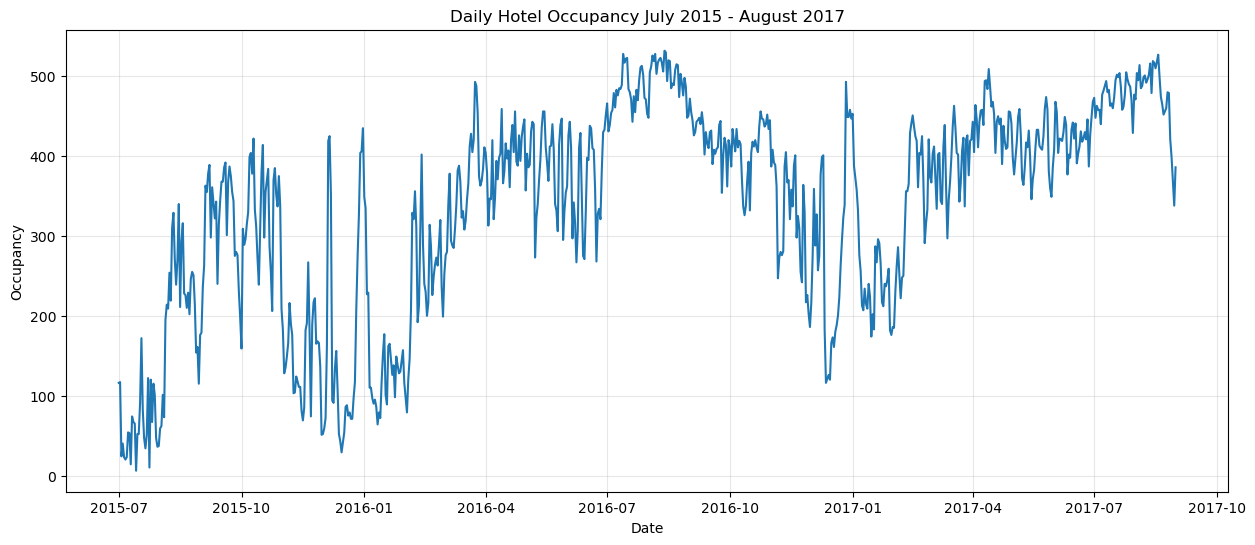

In [30]:
#FIG 1
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_final, x="date", y="occupancy")
plt.title("Daily Hotel Occupancy July 2015 - August 2017")
plt.xlabel("Date")
plt.ylabel("Occupancy")
plt.grid(True, alpha=0.3)
plt.show()

#FIG 2:This bar plot indicates that on average the busiest days are as expected Fridays and Saturday, and Sundays are quiet. 
The fact that there is not a huge difference between midweek and weekends suggest that this a city hotel, meaning that they receive many business travelers base, unlike a resort hotel, this one stay bussy even on a Monday.

In [31]:
df_final["day_of_week"] = df_final["date"].dt.day_name() #dt.day_name() calls "what day of the week was on July 1st" 
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"] #I organise the days according to the week so they dont appear alphabetically
df_final["day_of_week"] = pd.Categorical(df_final["day_of_week"], categories=days_order, ordered=True)

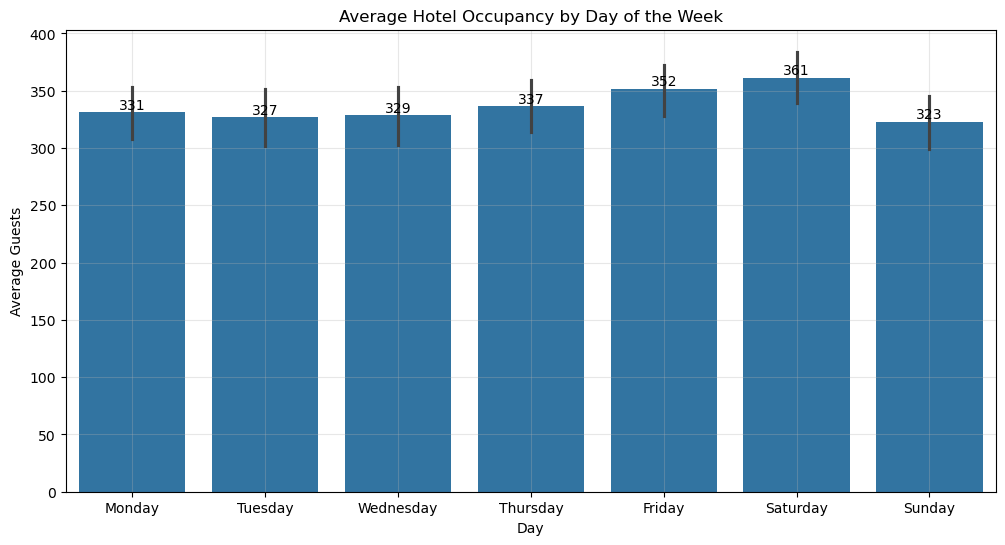

In [32]:
#FIG 2
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_final, x="day_of_week", y="occupancy") # Calculate the average guests for each day
ax.bar_label(ax.containers[0], fmt="%.0f")

plt.title("Average Hotel Occupancy by Day of the Week")
plt.ylabel("Average Guests")
plt.xlabel("Day")
plt.grid(True, alpha=0.3)
plt.show()

#FIG 3:This plot have a huge contribution to this project, it indicates that on days where there is No event (0.0), the hotel had high occupancy, could be probably the good weather or external conditions. 
Notably, even with No events and Poor weather, the occupancy is very high, up to 465 guests, suggesting that probably people do not care too much about the weather, they still travel. Another possible reason connected to the previous plot, is that on the event data set, it only contain events like concerts or football games, but Dublin is known for having  a busy corporate conference and tech industry calendar, so this can explain why midweek is very busy. 

Right in the middle, there is a dark spot, where the weather is poor and there is an event marked as 1, which means it has a small impact on the hotel, but it jumps to the eye that is the lowest occupancy with only 117 guests. Looking closely to the event, it is actually Christmas day, and also a very rainy day with aprox 20mm precipitation, so this combination result normal considering there are no busines working on Dublin and tourists are at home with their families. 

In [33]:
#Verifying what that purple negative number on my plot means, it is actually Christmas day. 
df_final[(df_final["event_impact"] == 1) &  
         (df_final["weather_quality"] == "Poor/Wet") & 
         (df_final["occupancy"] < 150)]

,date,rain,maxt,mint,weather_quality,event_name,event_impact,occupancy,adr,day_of_week
177,2015-12-25,21.9,13.4,3.0,Poor/Wet,Christmas day,1,117.0,74.806786,Friday


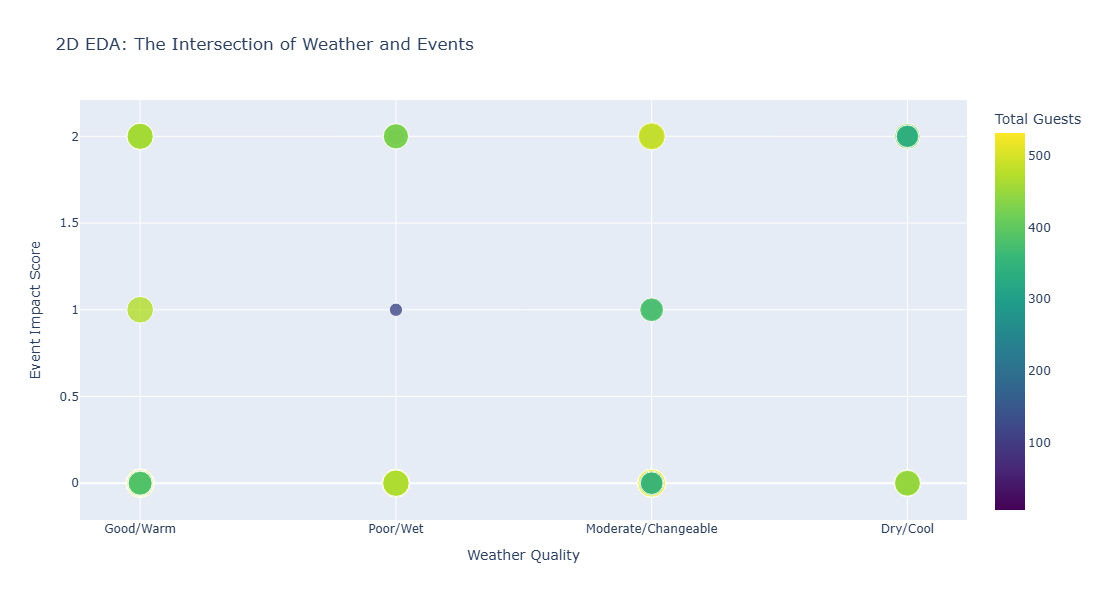

In [61]:
#FIG 3
fig = px.scatter(  
    df_final, 
    x="weather_quality", 
    y="event_impact", 
    color="occupancy",
    size="occupancy",  #Makes busier days physically larger
    opacity=0.8,
    width=800,        
    height=600,
    color_continuous_scale="Viridis", #Color gradient
    title="2D EDA: The Intersection of Weather and Events",
    labels={
        "weather_quality": "Weather Quality ",
        "event_impact": "Event Impact Score",
        "occupancy": "Total Guests"
    }
)

fig.show()

FIG 4: This is a very surprising plot, April-May peak at about 430 guests, whereas July downs to about 320 guests. This is critical to understand because this means that Spring is the busiest time of the year, not June, July and August as the summer indicates. This information helps to the model to avoid understaff on spring and overstaff in July.  

In [35]:
df_final["month_num"] = df_final["date"].dt.month #I bring "month_num" from my final data set

month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"} #I map the months again to be able to use them for this plot

df_final["month_name"] = df_final["month_num"].map(month_names) #I map the months again so I can display them properly fopr this plot
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] # I ordered them so they dont appear alphabetically
df_final["month_name"] = pd.Categorical(df_final["month_name"], categories=month_order, ordered=True)



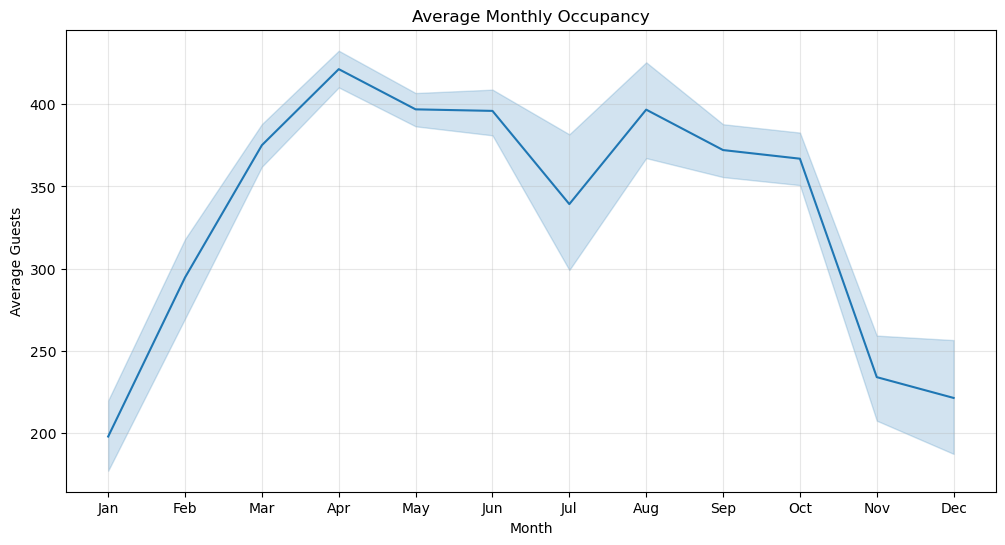

In [36]:
#FIG 4
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_final, x="month_name", y="occupancy")
plt.title("Average Monthly Occupancy")
plt.ylabel("Average Guests")
plt.xlabel("Month")
plt.grid(True, alpha=0.3)
plt.show()

FIG 5: As expected, on average, the Good weather is the highest occupancy with 372 guests. What is surprising at the beginning is that the Dry weather represent less guests than Poor days, once I looked closely, I can say that Poor/Wet days are spread along all the year in Ireland, it can be some spells on Spring, winter and Autumn periods, and that pulls the average up, whereas the Dry day belong only to summer days.  


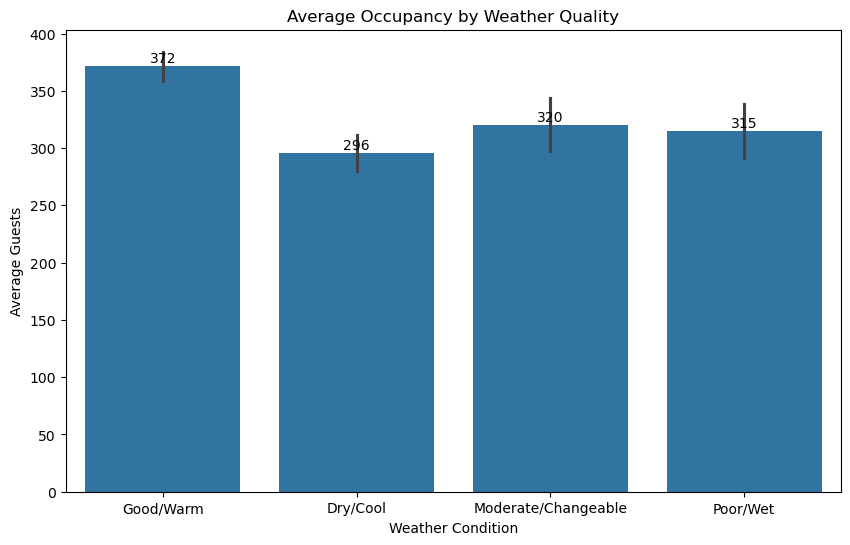

In [37]:
#FIG 5
plt.figure(figsize=(10, 6))
weather_order = ["Good/Warm", "Dry/Cool", "Moderate/Changeable", "Poor/Wet"] #Define the order to show progression from best to worst weather

ax = sns.barplot(data=df_final, x="weather_quality", y="occupancy", 
                 order=weather_order)
ax.bar_label(ax.containers[0], fmt="%.0f") #Add numerical labels on top of the bars for clarity

plt.title("Average Occupancy by Weather Quality")
plt.ylabel("Average Guests")
plt.xlabel("Weather Condition")
plt.show()

FIG 6:Heatmap

ADR= average Daily Rate and Occupancy have a high correlation, that is expected, the more guests check in, the more rate the hotel gets.

Max temperature and occupancy have a .33 moderated positive correlation, also expected, more temperature means more occupancy.


Something to have in consideration is that the events have a very weak correlation with occupancy, only .05, this may not be ideal but take in consideration that the dataset only contains a few events along all the year, the event data set contain 793 rows/days and only 29 of them have an event registered. 

Occupancy and Average Daily rate vs Rain: They exhibit low linear correlations, confirming what we said before, the rainy days impact a little bit, -.09 and -.04 are not too low actually, as we said, Dublin is a very busy city for Business guests, no metter the weather. 


In [38]:
print(f"Total days WITH any event: {(df_final['event_impact'] > 0).sum()}")
print(f"Total days in dataset: {len(df_final)}")

Total days WITH any event: 29
Total days in dataset: 793


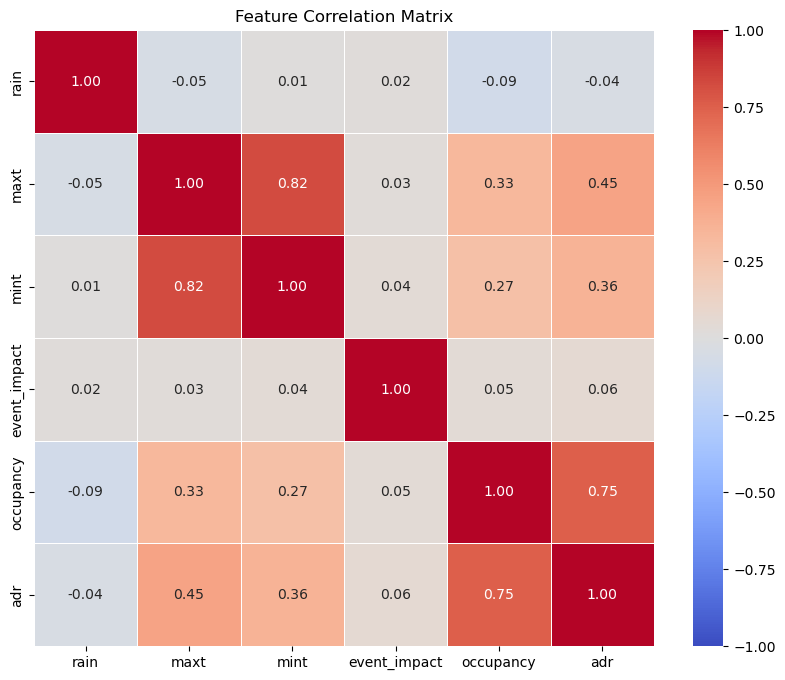

In [39]:
#FIG 6
numeric_cols = df_final.select_dtypes(include=["float64", "int64"]).columns #Select only numeric columns
corr_matrix = df_final[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1,vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

In [40]:
df_final["month_num"] = df_final["date"].dt.month #month and day were already created before, i'll just bring them again here
df_final["day_num"] = df_final["date"].dt.dayofweek


In [41]:
df_final["occupancy_yesterday"] = df_final["occupancy"].shift(1)#shift mean to move the occupancy values by one row
display(df_final["occupancy_yesterday"].head(15))

0       NaN
1     116.0
2     117.0
3      24.0
4      40.0
5      23.0
6      20.0
7      23.0
8      54.0
9      53.0
10     14.0
11     74.0
12     67.0
13     65.0
14      6.0
Name: occupancy_yesterday, dtype: float64

In [42]:
df_final["occupancy_7d_avg"] = df_final["occupancy"].shift(1).rolling(window=7).mean()#I avoided to use the today's occupancy by using .shift, 
#now I'll take the average of 7 days to find a trend in a determined time of 7 days. 
display(df_final["occupancy_7d_avg"].head(15))

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7     51.857143
8     43.000000
9     33.857143
10    32.428571
11    37.285714
12    43.571429
13    50.000000
14    47.571429
Name: occupancy_7d_avg, dtype: float64

In [43]:
df_final["week_of_year"] = pd.to_datetime(df_final["date"]).dt.isocalendar().week.astype(int)
display(df_final["week_of_year"].head(15))

0     27
1     27
2     27
3     27
4     27
5     28
6     28
7     28
8     28
9     28
10    28
11    28
12    29
13    29
14    29
Name: week_of_year, dtype: int32

In [44]:
df_final["occupancy_last_week"] = df_final["occupancy"].shift(7)
display(df_final["occupancy_last_week"].head(8))

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
5      NaN
6      NaN
7    116.0
Name: occupancy_last_week, dtype: float64

In [45]:
df_final["occupancy_last_year"] = df_final["occupancy"].shift(364)

In [46]:

df_model = df_final.dropna(subset=["occupancy_yesterday", "occupancy_7d_avg","occupancy_last_week","occupancy_last_year"]).copy() 
#By moving the rows, some of them may be empty (NAN), here I drop them 


In [47]:
#One hote encoding

df_model_encoded = pd.get_dummies( #It turn text/categories into columns of 1s and 0s.
    df_model, 
    columns=["day_of_week", "weather_quality"], #I encoded 'day_of_week' because Monday isn't "less than" Sunday
    prefix=["day", "weather"],
    dtype=int
)


print("New encoded columns added:")
print([col for col in df_model_encoded.columns if "day_" in col or "weather_" in col])

df_model_encoded.head()

New encoded columns added:
['day_num', 'day_Monday', 'day_Tuesday', 'day_Wednesday', 'day_Thursday', 'day_Friday', 'day_Saturday', 'day_Sunday', 'weather_Dry/Cool', 'weather_Good/Warm', 'weather_Moderate/Changeable', 'weather_Poor/Wet']


,date,rain,maxt,mint,event_name,event_impact,occupancy,adr,month_num,month_name,...,day_Tuesday,day_Wednesday,day_Thursday,day_Friday,day_Saturday,day_Sunday,weather_Dry/Cool,weather_Good/Warm,weather_Moderate/Changeable,weather_Poor/Wet
364,2016-06-29,1.3,18.4,11.8,No Event,0,433.0,118.501216,6,Jun,...,0,1,0,0,0,0,0,0,1,0
365,2016-06-30,1.2,18.4,10.8,No Event,0,451.0,99.910752,6,Jun,...,0,0,1,0,0,0,0,0,1,0
366,2016-07-01,4.1,16.4,10.2,No Event,0,466.0,105.008652,7,Jul,...,0,0,0,1,0,0,0,0,1,0
367,2016-07-02,0.2,18.2,9.6,No Event,0,431.0,118.109500,7,Jul,...,0,0,0,0,1,0,0,1,0,0
368,2016-07-03,0.0,19.3,11.8,No Event,0,439.0,116.991412,7,Jul,...,0,0,0,0,0,1,0,1,0,0


In [48]:
#I call all the columns I created in the One Hot encoded 
encoded_cols = [col for col in df_model_encoded.columns if ('day_' in col or 'weather_' in col) and col != 'day_num']

#This technique sin/cos will transform months and weeks in circular time features. 
#Considare a full circle as Pi X2 and Sine/Cosine as coordenates 
df_model_encoded["month_sin"] = np.sin(2 * np.pi * df_model_encoded["month_num"] / 12)
df_model_encoded["month_cos"] = np.cos(2 * np.pi * df_model_encoded["month_num"] / 12)

df_model_encoded["week_sin"] = np.sin(2 * np.pi * df_model_encoded["week_of_year"] / 52)
df_model_encoded["week_cos"] = np.cos(2 * np.pi * df_model_encoded["week_of_year"] / 52)

df_model_encoded = df_model_encoded.dropna()

features = ["maxt", "rain", "event_impact", "month_sin", "month_cos", "week_sin",
"week_cos", "occupancy_yesterday", "occupancy_7d_avg", "occupancy_last_week", "occupancy_last_year","adr",] + encoded_cols

X = df_model_encoded[features]  #Define features and targets
y = df_model_encoded["occupancy"]


#This function will keep the chronological order of my data, this will avoid that my model cheat
split_index = int(len(X) * 0.8) #I used the standard 80/20 split

X_train = X.iloc[:split_index]#.loc(integer location) asign a position to the rows, since the model doesnt know hoe to read dates
X_test = X.iloc[split_index:] #Everything inside the [is to select from which row to which row we are working] 

y_train = y.iloc[:split_index]#[:everything before the split]
y_test = y.iloc[split_index:]#[everything after the split:]

MODEL EVALUATION:

FIG 7:This box plot shows a race between Linear Regression, Decision Tree and Random forest across 5 different Time Seties Splits. The purpose of this evaluation is to compare over all perfomance, not to measure the final performance.

If we look at the three R2, all of them are negative, not meaning exactly a bad thing, but the data set is actually not that big to learn reliable patterns. Once the actual model is runnung, the R2 improves significantly. 

Decision Tree: The cross-validation results show that no single model wins on both metrics simultaneously. Decision Tree has the lowest standard deviation (0.3983) suggesting it is the most consistent, however its R² of -0.5540 is the worst of the three, meaning it is consistently wrong, not consistently good. 

Linear Regression seems to have a box tall enough to ensuere that contains very volatile and unpredictible information. 

Finally Random Forest: This one shows a bit more compact box in comparision to Linear Regression, the data seems to be stable enough, and the consistency may not be the best but this model present to be the most reliable

Linear Regression and Randon Forest contain outlier split, representing their worst case performance. Linear Regression produced the most extreme outlier at approximately -3.5, Random Forest's outlier of approximately -1.8, confirming that even in its worst case scenario, RF remains the most reliable choice.


In [49]:
models = [] #Prepare the list of models I want to race
models.append(('LinearReg', LinearRegression()))
models.append(('DecisionTree', DecisionTreeRegressor(random_state=17)))
models.append(('RandomForest', RandomForestRegressor(random_state=17)))



tscv = TimeSeriesSplit(n_splits=5)#Time series splits the data in 5 separate exams for prediction, it generates 5 different scores


results = [] #Run the race and find out which model perform better
names = []
print("Model Evaluation R-Squared Score")

for name, model in models:
    #I use 'r2' (R-squared) because this is a regression problem
    cv_results = cross_val_score(model, X_train, y_train, cv=tscv, scoring='r2')
    results.append(cv_results)
    names.append(name)
    

    print(f"{name}: Average R2 = {cv_results.mean():.4f} (Std Dev = {cv_results.std():.4f})")# I print the R2 mean from the 5 splits I did before



Model Evaluation R-Squared Score
LinearReg: Average R2 = -0.3261 (Std Dev = 1.5365)
DecisionTree: Average R2 = -0.5540 (Std Dev = 0.3983)
RandomForest: Average R2 = -0.2470 (Std Dev = 0.8725)


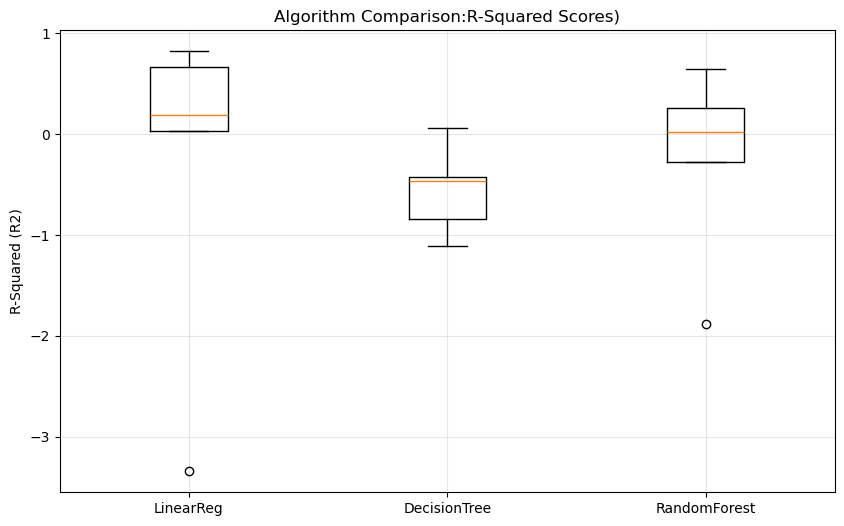

In [50]:
#FIG 7: 
plt.figure(figsize=(10, 6)) #Visualize the results 
plt.boxplot(results, labels=names)
plt.title("Algorithm Comparison:R-Squared Scores)")
plt.ylabel("R-Squared (R2)")
plt.grid(True, alpha=0.3)
plt.show()

IMPLEMENTATION OF RANDOM FOREST MODEL

The model achieved a final R-squared of 0.7133, meaning it successfully explains 71% of the variation in daily hotel occupancy. In practical terms, the model understands the patterns well enough to make reliable predictions for most days. 

The Average Error of 16.66 guests means that on a typical day the model's prediction is only about 17 guests away from the real number,  it represents roughly a 3 or 4% mistake rate. 

In [51]:
#Now I built the actual Random Forest model
rf_model = RandomForestRegressor(n_estimators=200, random_state=17) #I'll create 100 trees and I'll choose 17 as random state again  
rf_model.fit(X_train, y_train)


predictions = rf_model.predict(X_test)#Final scores
print("FINAL Random Forest R-squared:", round(r2_score(y_test, predictions), 4))
print("FINAL Average Error (Guests):", round(mean_absolute_error(y_test, predictions), 2))

FINAL Random Forest R-squared: 0.7133
FINAL Average Error (Guests): 16.66


FIG 8 : This chart shows which features the Random Forest relied on most to make its predictions. The result is very clear, occupancy_yesterday dominates at 0.80, meaning 80% of the model's prediction power comes from just knowing yesterday's occupancy. This makes complete sense with real nightly occupancy data, if 450 guests are sleeping in the hotel tonight, most of them booked for multiple nights and will still be there tomorrow.

The_7 day average comes second at around 0.06, and occupancy_last_year third at 0.03. Weather categories, events, rain and day of week all scored near zero. This doesn't mean they are useless, it confirms that for a city hotel, pre-existing bookings and seasonal momentum are far stronger signals than daily weather or individual events.


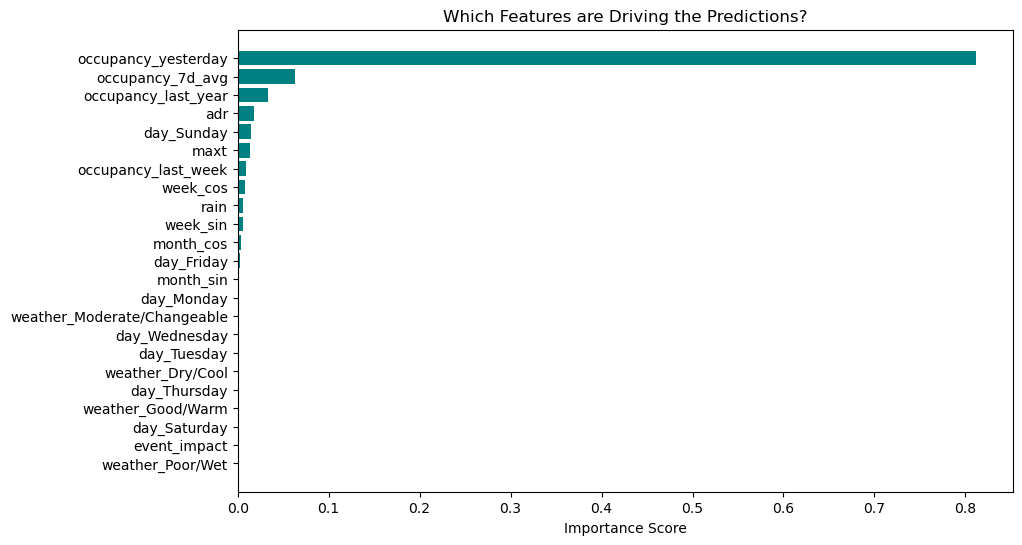

In [52]:
#FIG 8
importances = rf_model.feature_importances_ # Get importance from the model
feature_names = X.columns
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color="teal")
plt.title("Which Features are Driving the Predictions?")
plt.xlabel("Importance Score")
plt.show()

FIG 9 :The scatter shows a strong positive trend along the diagonal, confirming the model learned real patterns. Most dots cluster tightly around the line in the 450–525 guest range. At the lower end around 330–380 guests, the model slightly overpredicts.
Overall the pattern is strong and consistent

In [53]:
print(f"Test period contains {len(y_test)} days")


Test period contains 86 days


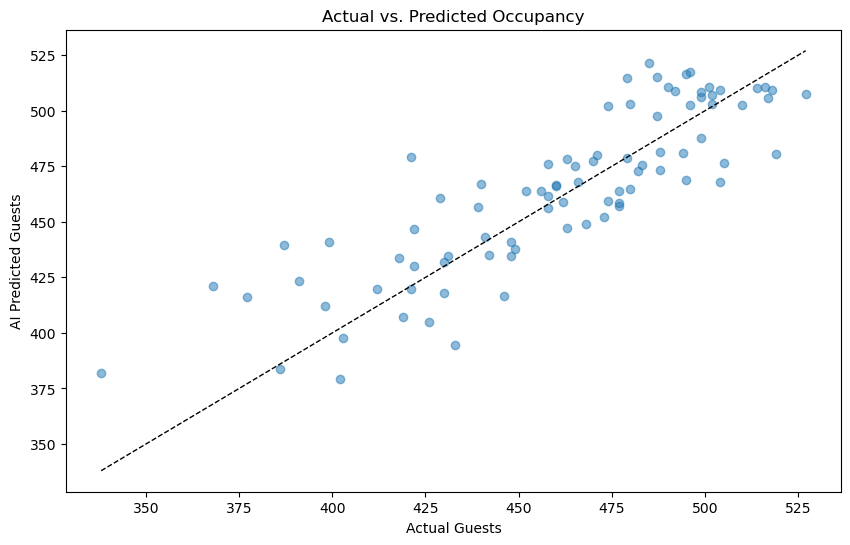

In [54]:
#FIG 9
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=1)
plt.xlabel("Actual Guests")
plt.ylabel("AI Predicted Guests")
plt.title("Actual vs. Predicted Occupancy")
plt.show()

PRESENTING FINAL RESULTS

FIG 10:
This histogram shows how big the model's mistakes were across the test days. The red dashed line at zero represents a perfect prediction. Bars to the left mean the model overpredicted, bars to the right mean it underpredicted.

The tallest bar sits just slightly to the left of zero, meaning the most common error was a small overprediction of around 5 to 10 guests. This is actually a safe bias for a staffing tool but it is better to schedule one or two extra staff than to be caught understaffed on a busy night.

The distribution has a slight left skew, meaning the model overpredicts more often than it underpredicts. The errors on the negative side stretch further, reaching up to -60 guests in the worst case, while the positive side only goes up to about +40. The bulk of the errors however are concentrated between -20 and +20, which combined with an average error of only 16 guests represents a reliable and operationally acceptable level of accuracy for daily staffing decisions.

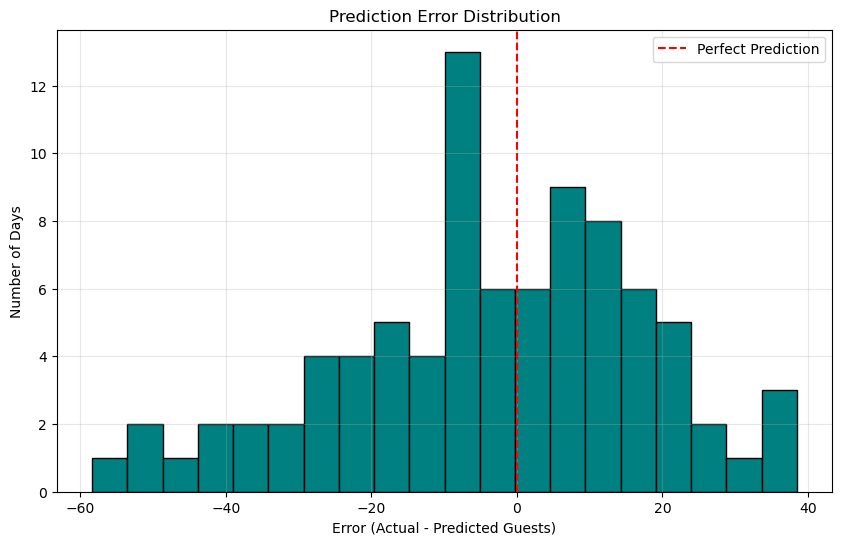

In [55]:
#FIG 10
errors = y_test.values - predictions

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=20, color="teal", edgecolor="black")
plt.axvline(x=0, color="red", linestyle="--", label="Perfect Prediction")
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted Guests)")
plt.ylabel("Number of Days")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

FIG 11
The model captures the general upward trend across the test period and follows the weekly rhythm of peaks and dips. The biggest gap between lines appears around day 85, where occupancy dropped sharply. When a sudden drop happened, the model didn't fully anticipate it because it had no similar pattern to learn from in the training data.
The ratio is defined as a variable that can be updated by the hotel manager,the conversion to staff numbers is a business decision, not a machine learning one.

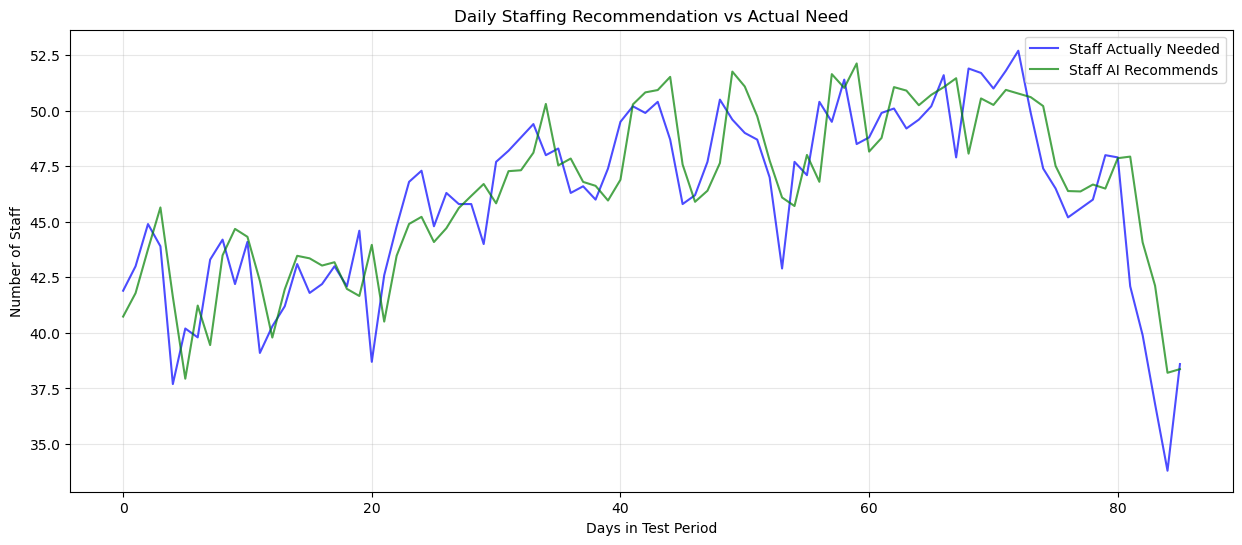

In [59]:
#FIG 11

staff_ratio = 10

predicted_staff = predictions / staff_ratio
actual_staff = y_test.values / staff_ratio

plt.figure(figsize=(15, 6))
plt.plot(actual_staff, label="Staff Actually Needed", color="blue", alpha=0.7)
plt.plot(predicted_staff, label="Staff AI Recommends", color="green", alpha=0.7)
plt.title("Daily Staffing Recommendation vs Actual Need")
plt.xlabel("Days in Test Period")
plt.ylabel("Number of Staff")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

FIG 12: This format represents the direct practical output of the project. A hotel manager can look at this chart the week before and know how many staff to schedule each day without any further calculation. The numbers on top of each bar remove any ambiguity, making this a ready-to-use planning tool that directly addresses the original project objective of preventing overstaffing and understaffing. 

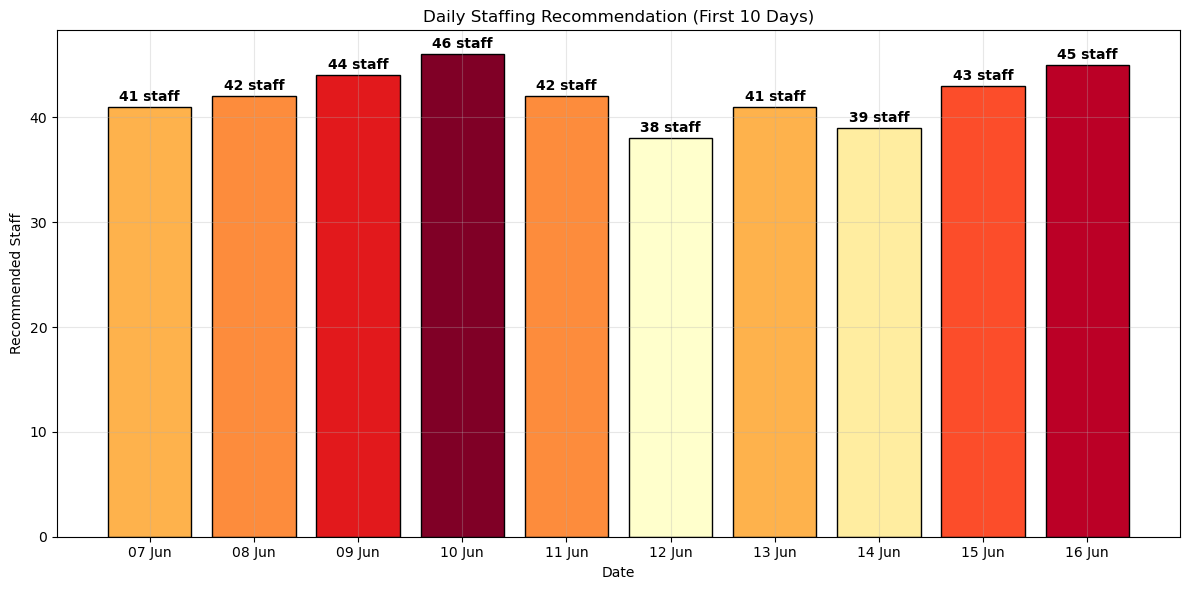

In [58]:
#FIG 12

staff_ratio = 10

results_df = pd.DataFrame({
    "date": pd.to_datetime(df_model_encoded.iloc[split_index:]["date"].values),
    "predicted_staff": (predictions / staff_ratio).round().astype(int)
})

top10 = results_df.head(10).copy()
top10["day_label"] = top10["date"].dt.strftime("%d %b")

# Colors based on VALUE not position
norm = mcolors.Normalize(vmin=top10["predicted_staff"].min(), 
                         vmax=top10["predicted_staff"].max())
colors = [cm.YlOrRd(norm(val)) for val in top10["predicted_staff"]]

plt.figure(figsize=(12, 6))
bars = plt.bar(top10["day_label"], top10["predicted_staff"], 
               color=colors, edgecolor="black")

for bar, value in zip(bars, top10["predicted_staff"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{value} staff", ha="center", va="bottom", fontweight="bold")

plt.title("Daily Staffing Recommendation (First 10 Days)")
plt.xlabel("Date")
plt.ylabel("Recommended Staff")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()